<!-- dom:TITLE: Project 3 - Task # 1 Data Preprocessing-->
# Project 3 - Task # 1 Data Preprocessing
<!-- dom:AUTHOR: Sivert Tilset and xxx and xxx -->
<!-- Author: -->  
**Sivert Tilset (273412) and Robel Weldemichael(267200) and Mohammed Jama()**

Date: **23.10.2024**



# Abstract

In this task, we focused on preparing and optimizing a geophysical dataset for analysis through data processing and feature selection. Initial data processing involved identifying and handling missing values and duplicates, ensuring data quality and integrity. We confirmed that all data entries were in the float64 format, appropriate for numerical analysis, which helped maintain precision in our calculations.

Following data cleaning, we performed feature selection by analyzing the correlation matrix to assess the relationships between compressional-wave velocity (Vp) and the features shear-wave velocity (Vs), bulk density (DEN), and neutron porosity (NEU). All three features exhibited strong correlations with Vp, exceeding our selection threshold (|r| > 0.8). Based on this analysis, we retained all three features, as each demonstrated significant predictive potential for the target variable, Vp.


# Introduction

Following the reporting format, provide intrdoction about data, data preporcessing and its role in machine learning.....what should be done?
Show also references related to the data preprocessing....

# Step 1: Import Important Libraries

In [39]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Import File

In [40]:
df = pd.read_excel('ProjectData2024.xlsx')

# Step 3: Check about the dataframe
    

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Vs      1187 non-null   float64
 1   DEN     1185 non-null   float64
 2   NEU     1184 non-null   float64
 3   Vp      1182 non-null   float64
dtypes: float64(4)
memory usage: 37.5 KB


We can observe that all columns have the data type float64, which is suitable for numerical operations. Since this type provides the necessary precision for our analysis, there’s no need to change the data type for any column.

In [42]:
# If we want to display the first five and the last twenty of the dataframe dataset, we use .tail(), .tail(20)
df.head(), df.tail(20)

(         Vs     DEN     NEU        Vp
 0  1.676857  2.3767  0.2759  3.045533
 1  1.677172  2.2101  0.2524  2.974779
 2  1.676252  2.1419  0.2591  2.881411
 3  1.677030  2.1660  0.2589  2.930981
 4  1.684534  2.1193  0.2596  2.910094,
             Vs     DEN     NEU        Vp
 1175  1.830254  2.4994  0.1639  3.795903
 1176       NaN  2.4727  0.1738  3.786439
 1177       NaN  2.5265  0.1747  3.813609
 1178       NaN  2.4992  0.1765  3.723357
 1179  1.783920  2.4869  0.1765  3.706401
 1180  1.722414  2.5298  0.1772  3.587773
 1181  1.701131     NaN  0.1701  3.589332
 1182  1.698956     NaN  0.1760  3.642491
 1183  1.765315     NaN  0.1715  3.694317
 1184  1.769975     NaN  0.1683  3.793243
 1185  1.796977  2.4993  0.1504  3.866460
 1186  1.787030  2.4953  0.1464  3.920207
 1187  1.781640  2.5650  0.1395       NaN
 1188  1.773772  2.5043  0.1498       NaN
 1189  1.723615  2.5082  0.1579       NaN
 1190  1.710900  2.5386  0.1686       NaN
 1191  1.730096  2.5394  0.1721  3.807987
 1192  1.

We can observe that there are NaN values scattered throughout the data, indicating missing entries in some columns. Addressing these missing values will be necessary for accurate data analysis and modeling.

# Step 4 Processing zero and Nan values

Data must be float for further modeling
Based on the information obtained from the previous cell, we dont need to change the data type because the datatype is allready float but what we need to do is change the zero entries to nan to make our data cleaner . 

     

## step 4.1 : convert zero entries to nan (not a numeric)

In [43]:
# Replace zero values with nan
df.replace(0, np.nan, inplace=True)
df.info()
df.head(), df.tail(20)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Vs      1187 non-null   float64
 1   DEN     1185 non-null   float64
 2   NEU     1184 non-null   float64
 3   Vp      1182 non-null   float64
dtypes: float64(4)
memory usage: 37.5 KB


(         Vs     DEN     NEU        Vp
 0  1.676857  2.3767  0.2759  3.045533
 1  1.677172  2.2101  0.2524  2.974779
 2  1.676252  2.1419  0.2591  2.881411
 3  1.677030  2.1660  0.2589  2.930981
 4  1.684534  2.1193  0.2596  2.910094,
             Vs     DEN     NEU        Vp
 1175  1.830254  2.4994  0.1639  3.795903
 1176       NaN  2.4727  0.1738  3.786439
 1177       NaN  2.5265  0.1747  3.813609
 1178       NaN  2.4992  0.1765  3.723357
 1179  1.783920  2.4869  0.1765  3.706401
 1180  1.722414  2.5298  0.1772  3.587773
 1181  1.701131     NaN  0.1701  3.589332
 1182  1.698956     NaN  0.1760  3.642491
 1183  1.765315     NaN  0.1715  3.694317
 1184  1.769975     NaN  0.1683  3.793243
 1185  1.796977  2.4993  0.1504  3.866460
 1186  1.787030  2.4953  0.1464  3.920207
 1187  1.781640  2.5650  0.1395       NaN
 1188  1.773772  2.5043  0.1498       NaN
 1189  1.723615  2.5082  0.1579       NaN
 1190  1.710900  2.5386  0.1686       NaN
 1191  1.730096  2.5394  0.1721  3.807987
 1192  1.

## Step 4.2 Drop the Nan entries 

we drop all Nan entries because they are not proccessable.

In [44]:
# Remove the nan....we use dropna() function
# inplace = True, it means that once we remove the nan, use the cleaned data and save it as df1

df.dropna(inplace= True)

In [45]:
# Check if null exists (Unrecorded dataset, or blank), not a numeric
# Method 1: isnull()
miss_data= df.isnull().sum()

# Method 2: isna()
#miss_data= df.isna().sum()

In [46]:
# Check null number of data exists 
print(miss_data)

Vs     0
DEN    0
NEU    0
Vp     0
dtype: int64


Now we have no remaining missing value as we removed all the nan values.

In [47]:
df.info()
df.head(), df.tail(20)

<class 'pandas.core.frame.DataFrame'>
Index: 1164 entries, 0 to 1192
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Vs      1164 non-null   float64
 1   DEN     1164 non-null   float64
 2   NEU     1164 non-null   float64
 3   Vp      1164 non-null   float64
dtypes: float64(4)
memory usage: 45.5 KB


(         Vs     DEN     NEU        Vp
 0  1.676857  2.3767  0.2759  3.045533
 1  1.677172  2.2101  0.2524  2.974779
 2  1.676252  2.1419  0.2591  2.881411
 3  1.677030  2.1660  0.2589  2.930981
 4  1.684534  2.1193  0.2596  2.910094,
             Vs     DEN     NEU        Vp
 1160  1.877343  2.5392  0.1479  3.865822
 1161  1.861162  2.5688  0.1372  3.835718
 1162  1.819632  2.5525  0.1317  3.816999
 1163  1.821284  2.5467  0.1332  3.810657
 1164  1.798054  2.5532  0.1442  3.783755
 1165  1.823948  2.5043  0.1615  3.811005
 1166  1.835857  2.4815  0.1743  3.780465
 1167  1.868822  2.5001  0.1835  3.776137
 1168  1.883659  2.4615  0.1809  3.775632
 1169  1.892313  2.4193  0.1921  3.770448
 1170  1.923482  2.4631  0.1964  3.765808
 1171  1.907508  2.4433  0.1975  3.763428
 1174  1.834782  2.5383  0.1689  3.782694
 1175  1.830254  2.4994  0.1639  3.795903
 1179  1.783920  2.4869  0.1765  3.706401
 1180  1.722414  2.5298  0.1772  3.587773
 1185  1.796977  2.4993  0.1504  3.866460
 1186  1.

# Step 4.3 It is now time to save the cleaned data 

The file is now a float, removing all undesired entries and null values.
We will use this file for further data cleaning such as
    
- Duplicate detection and removal
       
- Outlier's detection and removal

In [48]:
# It is now time to save the float file....let as save it as clearning1
df.to_excel('Clearning1.xlsx', index=False)

# Step 5 Import the saved float file for outliers and duplicates clearning

## Step 5.1 Import the saved file 

In [49]:
# Import the saved file 

df1= pd.read_excel('Clearning1.xlsx').astype(float)
df1.info()
df1.head(), df1.tail()

# Results show that all blanks are removed by row-wise and the number of datasets is equal. It means that all are non-null (No blank)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1164 entries, 0 to 1163
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Vs      1164 non-null   float64
 1   DEN     1164 non-null   float64
 2   NEU     1164 non-null   float64
 3   Vp      1164 non-null   float64
dtypes: float64(4)
memory usage: 36.5 KB


(         Vs     DEN     NEU        Vp
 0  1.676857  2.3767  0.2759  3.045533
 1  1.677172  2.2101  0.2524  2.974779
 2  1.676252  2.1419  0.2591  2.881411
 3  1.677030  2.1660  0.2589  2.930981
 4  1.684534  2.1193  0.2596  2.910094,
             Vs     DEN     NEU        Vp
 1159  1.722414  2.5298  0.1772  3.587773
 1160  1.796977  2.4993  0.1504  3.866460
 1161  1.787030  2.4953  0.1464  3.920207
 1162  1.730096  2.5394  0.1721  3.807987
 1163  1.737664  2.5182  0.1791  3.826752)

## Step 5.2 Check if duplicate data exist and then remove 

In [50]:
# Check if duplicates exists....we use a function....duplicated()
# if True, it means that there is duplicates
# if False, it means that there is no duplicates

dups= df1.duplicated()
print(dups.any())


True


The output confirms that duplicate entries exist in the dataset. We’ll need to address these duplicates to ensure that our data is clean and that each entry is unique for accurate analysis.

In [52]:
# To list the duplicated samples and the total number of duplicates...
print(dups.sum())
print(df1[dups])

58
            Vs     DEN     NEU        Vp
1103  1.056314  2.3807  0.3371  2.588172
1104  1.053382  2.3766  0.3452  2.619560
1105  1.066399  2.3660  0.3426  2.626140
1106  1.064992  2.3538  0.3670  2.613025
1107  1.046916  2.3505  0.3509  2.597221
1108  1.033467  2.3533  0.3523  2.581377
1109  1.046970  2.3535  0.3317  2.590031
1110  1.029629  2.3574  0.3455  2.630902
1111  1.072748  2.3358  0.3216  2.584707
1113  1.211407  2.3670  0.3000  2.766731
1116  1.106032  2.3645  0.3233  2.633402
1117  1.072748  2.3358  0.3216  2.584707
1118  1.066803  2.3268  0.3452  2.571996
1119  1.066234  2.3441  0.3472  2.575603
1120  1.056314  2.3807  0.3371  2.588172
1121  1.053382  2.3766  0.3452  2.619560
1122  1.066399  2.3660  0.3426  2.626140
1123  1.064992  2.3538  0.3670  2.613025
1124  1.932877  2.5244  0.1774  3.839216
1125  1.896222  2.5230  0.1629  3.835414
1126  1.765182  2.5164  0.1566  3.728062
1127  1.769825  2.5001  0.1582  3.707501
1128  1.757684  2.5273  0.1603  3.722712
1129  1.79755

In [54]:
# Now drop the duplicates.....we use  .drop_duplicates()
# We use---inplace = True,.....it means that after removing the duplicates, we use the dataframe df1

df1.drop_duplicates(inplace = True)

In [55]:
# Check if the duplicates are removed...we use.....info()
dups= df1.duplicated()
print(dups.any())

False


Now it is exactly as we wanted it and all the duplicates are removed.

In [59]:
# It is now time to save the duplicates/blank clean data before we do oulier removal 

# Check null/blank and replace with nan.
df1.replace('', np.nan,inplace=True) 
df1.info()
df1.head(), df1.tail()



<class 'pandas.core.frame.DataFrame'>
Index: 1106 entries, 0 to 1115
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Vs      1106 non-null   float64
 1   DEN     1106 non-null   float64
 2   NEU     1106 non-null   float64
 3   Vp      1106 non-null   float64
dtypes: float64(4)
memory usage: 43.2 KB


(         Vs     DEN     NEU        Vp
 0  1.676857  2.3767  0.2759  3.045533
 1  1.677172  2.2101  0.2524  2.974779
 2  1.676252  2.1419  0.2591  2.881411
 3  1.677030  2.1660  0.2589  2.930981
 4  1.684534  2.1193  0.2596  2.910094,
             Vs     DEN     NEU        Vp
 1101  1.046970  2.3535  0.3317  2.590031
 1102  1.029629  2.3574  0.3455  2.630902
 1112  1.066803  2.3268  0.3452  7.000000
 1114  1.190001  2.3700  0.3008  2.721195
 1115  1.200000  2.3624  0.3284  2.707129)

# Step 6 Import the saved file for outline clearning clearning

In [60]:
df1.to_excel('CleanData2.xlsx', index = False)

## Step 6.1 Import the file

In [61]:
df2 = pd.read_excel('CleanData2.xlsx')
df2.shape

(1106, 4)

## Step 6.2 Check if outlier exists  and remove

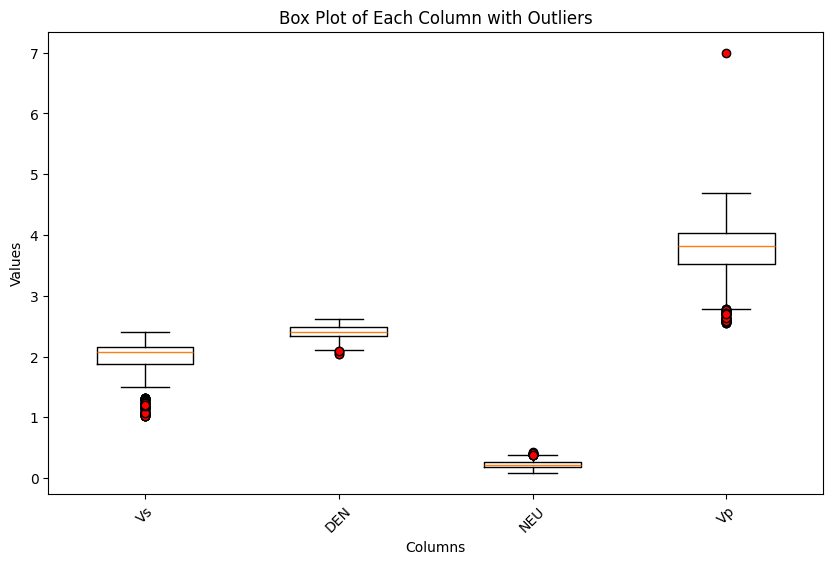

In [65]:
# We can use a box plot to see if an outlier exists. We can see the data after the whisker


# Generate a box plot with column names
plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
plt.boxplot(df2.values, widths=0.5, flierprops=dict(markerfacecolor='red', marker='o'))
plt.xticks(ticks=range(1, len(df2.columns) + 1), labels=df2.columns, rotation=45)  # Set x-axis labels with column names
plt.title("Box Plot of Each Column with Outliers")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()



In [67]:
# Detect and remove outliers for each column using the IQR method
df_no_outliers = df2.copy()  # Create a copy of the DataFrame to remove outliers

for column in df_no_outliers.columns:
    # Calculate Q1, Q3, and IQR for the column
    Q1 = df_no_outliers[column].quantile(0.25)
    Q3 = df_no_outliers[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter data within bounds for the current column
    df_no_outliers = df_no_outliers[(df_no_outliers[column] >= lower_bound) & (df_no_outliers[column] <= upper_bound)]

#  Check the shape to see how many rows were removed
print("Original data shape:", df2.shape)
print("Data shape after outlier removal:", df_no_outliers.shape)


Original data shape: (1106, 4)
Data shape after outlier removal: (1002, 4)
(1106, 4)


In [445]:
#It is now time time to save the outlier removed files in Excel

In [68]:
df_no_outliers.to_excel('CleanOutlier1.xlsx', index=False)

# Step 6 Feature Selection

    

## Step 6.1 Import Outlier removed and saved file

In [73]:
# Import the saved file'CleanOutlier1.xlsx'
 
df3 = pd.read_excel('CleanOutlier1.xlsx').astype(float)

In [74]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Vs      1002 non-null   float64
 1   DEN     1002 non-null   float64
 2   NEU     1002 non-null   float64
 3   Vp      1002 non-null   float64
dtypes: float64(4)
memory usage: 31.4 KB


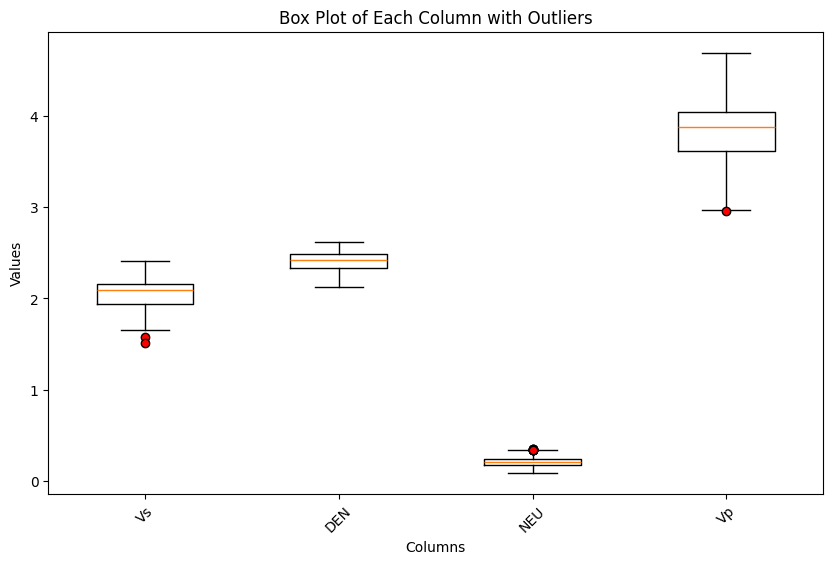

In [76]:
# Check if the outlier from the target is removed....you can see that no dataset after the whisker line
plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
plt.boxplot(df3.values, widths=0.5, flierprops=dict(markerfacecolor='red', marker='o'))
plt.xticks(ticks=range(1, len(df2.columns) + 1), labels=df2.columns, rotation=45)  # Set x-axis labels with column names
plt.title("Box Plot of Each Column with Outliers")
plt.xlabel("Columns")
plt.ylabel("Values")
plt.show()


## Step 6.2 Now construct heatmap to generate r-correlation


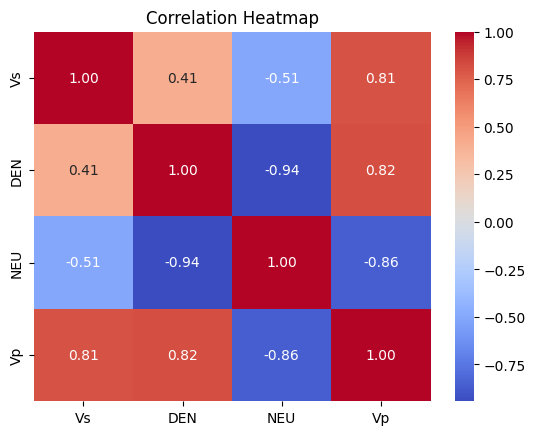

In [80]:

sns.heatmap(df3.corr(), annot=True, fmt=".2f", cmap="coolwarm")  # Choose your preferred cmap
plt.title("Correlation Heatmap")
plt.show()

## Step 6.3 Select a correlation matrix that is related to the y target based on the desired criteria (abs(r) >0.8)


In [99]:
correlation_matrix = df3.corr()  # Compute the correlation matrix

# Filter for correlations with 'Vp' that are greater than 0.8 in absolute value
vp_high_correlations = correlation_matrix['Vp'][abs(correlation_matrix['Vp']) > 0.8].drop('Vp')  # Exclude self-correlation

# Display the variables with high correlation to 'Vp' and their correlation values
print("Variables with correlation > 0.8 with 'Vp':")
print(vp_high_correlations)

Variables with correlation > 0.8 with 'Vp':
Vs     0.808240
DEN    0.820927
NEU   -0.863103
Name: Vp, dtype: float64


All three columns Vs, DEN, and NEU show a strong correlation with Vp, meeting our criteria (|r| > 0.8). Therefore, we don’t necessarily need to drop any of them.